In [ ]:
%ls opt/

bin@      dev/     lib@     media/  python-apt/         sbin@  tools/
boot/     etc/     lib32@   mnt/    python-apt.tar.xz*  srv/   usr/
content/  home/    lib64@   opt/    root/               sys/   var/
datalab/  kaggle/  libx32@  proc/   run/                tmp/


In [30]:
!pwd

/


In [33]:
%ls 

bin@      dev/     lib@     media/  python-apt/         sbin@  tools/
boot/     etc/     lib32@   mnt/    python-apt.tar.xz*  srv/   usr/
content/  home/    lib64@   opt/    root/               sys/   var/
datalab/  kaggle/  libx32@  proc/   run/                tmp/


kernel_manager_proxy*  language_service*


In [9]:
pip install --upgrade pip setuptools wheel

In [ ]:
%pip install -e .

Obtaining file:///content/drive/.shortcut-targets-by-id/1c0dZqcVgRaULmckLrWSMToFGpJXTtkuN/Project
  Preparing metadata (setup.py) ... done
  Attempting uninstall: deapsleep
    Found existing installation: deapsleep 0.1.0
    Uninstalling deapsleep-0.1.0:
      Successfully uninstalled deapsleep-0.1.0
  Running setup.py develop for deapsleep


In [ ]:
import deapsleep
import sys
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [ ]:
def optimize(probtype, probname, version, n_runs, ngen, n_var, indD_rate=None, popD_rate=None, indD_strg=None, **kwargs):
    cmd = f"python3 -m deapsleep.main.optimize --config {probtype}.{probname} -i " \
          f"--version={version} --n_runs={n_runs} --ngen={ngen} --n_var={n_var} "

    if indD_rate is not None:
        cmd += f"--indD_rate='{indD_rate}' "

    if popD_rate is not None:
        cmd += f"--popD_rate='{popD_rate}' "

    if indD_strg is not None:
        cmd += f"--indD_strg='{indD_strg}' "

    for key, value in kwargs.items():
        if isinstance(value, bool):
            if value:
                cmd += f"--{key} "
        else:
            cmd += f"--{key}={value} "

    get_ipython().system(cmd)

def compare(probtype, probname, version1, version2, **kwargs):
    cmd = f"python3 -m deapsleep.main.compare --config {probtype}.{probname} -i " \
          f"--version1={version1} --version2={version2} "

    for key, value in kwargs.items():
        if isinstance(value, bool):
            if value:
                cmd += f"--{key} "
        else:
            cmd += f"--{key}={value} "

    get_ipython().system(cmd)

In [ ]:
probtype = 'single'
probname = 'rastrigin'

n_runs = 30
ngen = 500
n_var = 30

indD_rate=0.7
popD_rate=0.7
indD_strg=2

if n_var == 'None':
  from pymoo.problems import get_problem
  nvar = get_problem(probname).n_var
  name = f'{n_runs}r_{ngen}g_{nvar}v'
else:
  name = f'{n_runs}r_{ngen}g_{n_var}v'

base_version = name + '_base'
indD_version = name + f'_{indD_rate}rate_indD'

# Individual Dropout
optimize(probtype, probname, indD_version, n_runs, ngen, n_var, indD_rate=indD_rate, indD_strg=indD_strg)

Optimizing rastrigin: 100% 30/30 [27:53<00:00, 55.79s/run]


In [ ]:
# Baseline
optimize(probtype, probname, base_version, n_runs, ngen, n_var)

Optimizing zdt4:  57% 17/30 [2:55:23<3:16:29, 906.91s/run] 

In [ ]:
# Individual Dropout
optimize(probtype, probname, indD_version, n_runs, ngen, n_var, indD_rate=indD_rate, indD_strg=indD_strg)

Optimizing ackley: 100% 30/30 [19:15<00:00, 38.50s/run]


In [ ]:
# Population Dropout
optimize(probtype, probname, popD_version, n_runs, ngen, n_var, popD_rate=popD_rate)

Optimizing ackley: 100% 30/30 [03:42<00:00,  7.41s/run]


In [ ]:
# Individual and Population Dropout
optimize(probtype, probname, indD_popD_version, n_runs, ngen, n_var, indD_rate=indD_rate, popD_rate=popD_rate, indD_strg=indD_strg)

Optimizing ackley: 100% 30/30 [30:17<00:00, 60.58s/run]


Comparing... /content/drive/.shortcut-targets-by-id/1c0dZqcVgRaULmckLrWSMToFGpJXTtkuN/Project/deapsleep/src/metrics/so_metrics.py:150: UserWarning: Insufficient budget for Baseline.
  warnings.warn(f'Insufficient budget for {label}.')
/content/drive/.shortcut-targets-by-id/1c0dZqcVgRaULmckLrWSMToFGpJXTtkuN/Project/deapsleep/src/metrics/so_metrics.py:150: UserWarning: Insufficient budget for Individual & Population Dropout.
  warnings.warn(f'Insufficient budget for {label}.')
done.


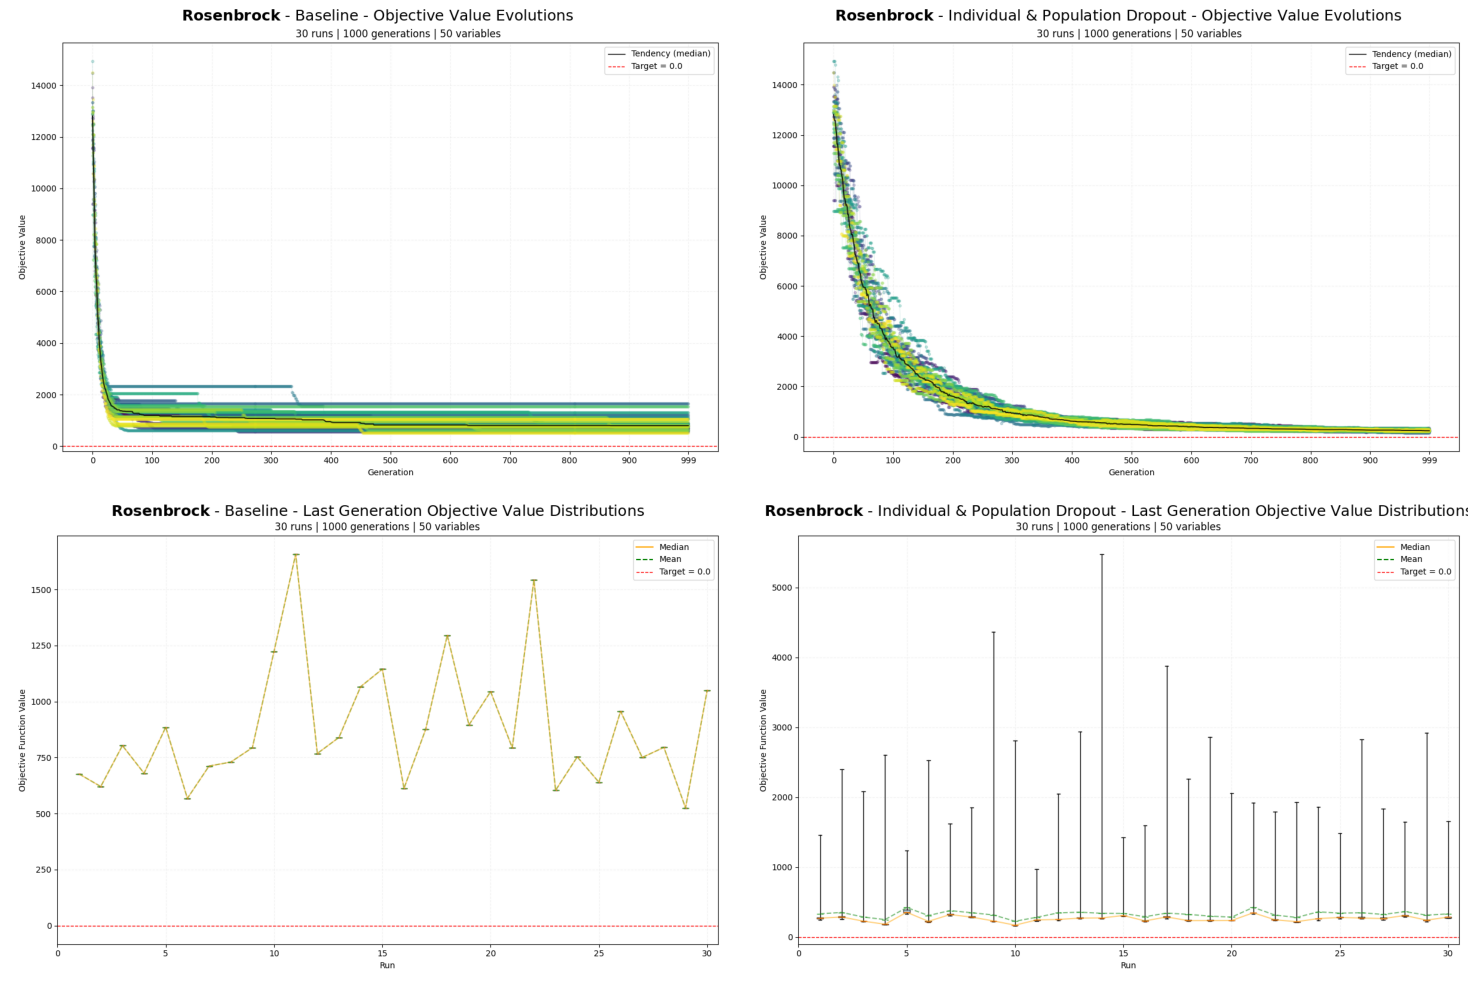

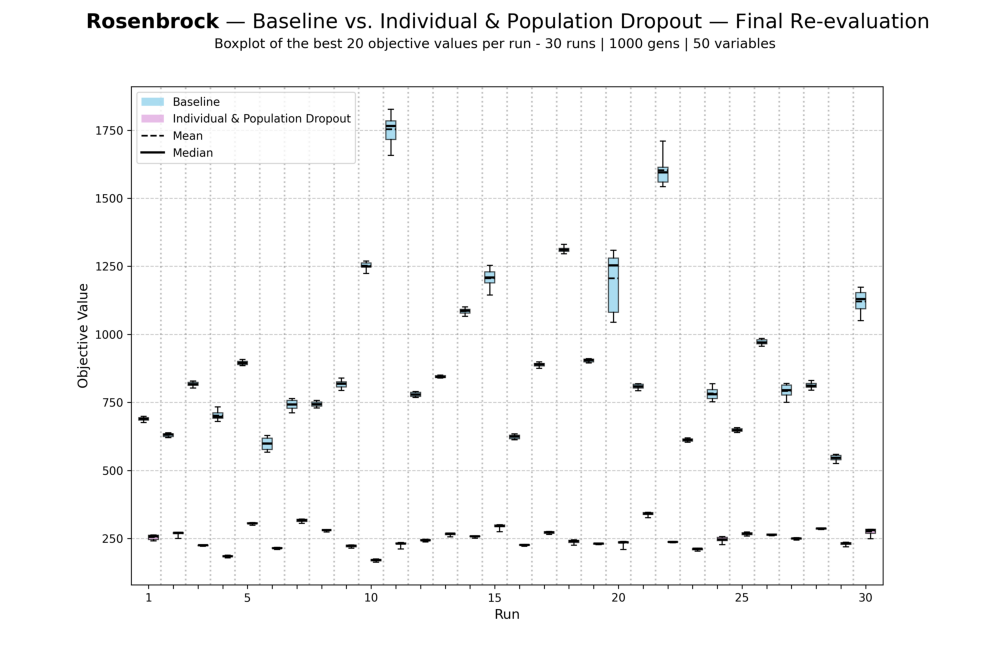


{
    "Total Runs": 30,
    "Baseline Wins": 0,
    "Individual & Population Dropout Wins": 30,
    "Ties": 0,
    "Mean best objective value across runs - Baseline": 876.6791349390452,
    "Std best objective value across runs - Baseline": 275.67740539759654,
    "Mean best objective value across runs - Individual & Population Dropout": 241.68742504589792,
    "Std best objective value across runs - Individual & Population Dropout": 35.90209745468597,
    "Baseline Wins (%)": 0.0,
    "Individual & Population Dropout Wins (%)": 100.0,
    "Ties (%)": 0.0
}


In [ ]:
v1 = base_version
v2 = indD_popD_version

sys.stdout.write('Comparing... ')
sys.stdout.flush()
# Comparing two versions
compare(probtype, probname, v1, v2)
print('done.')

image_paths = [
    f"/content/drive/MyDrive/Project/deapsleep/experiments/results/{probtype}/{probname}/{v1}/evolution.png",
    f"/content/drive/MyDrive/Project/deapsleep/experiments/results/{probtype}/{probname}/{v2}/evolution.png",
    f"/content/drive/MyDrive/Project/deapsleep/experiments/results/{probtype}/{probname}/{v1}/last_stats_boxplot.png",
    f"/content/drive/MyDrive/Project/deapsleep/experiments/results/{probtype}/{probname}/{v2}/last_stats_boxplot.png"
    # ...
]

fig, axes = plt.subplots(len(image_paths)//2, 2, figsize=(15, 10))
axes = axes.ravel()

for i, ax in enumerate(axes):
    if i < len(image_paths):
        img = mpimg.imread(image_paths[i])
        ax.imshow(img)
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()
print()

plt.figure(figsize=(10, 8))

v1 = 'Baseline'
v2 = 'Individual & Population Dropout'

img = mpimg.imread(f"/content/drive/MyDrive/Project/deapsleep/experiments/results/{probtype}/{probname}/{v1}_{v2}_final_evaluation_grouped.png")
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

with open(f'/content/drive/MyDrive/Project/deapsleep/experiments/results/{probtype}/{probname}/{v1}_{v2}_comparison.txt') as f:
    print(f.read())

with open(f'/content/drive/MyDrive/Project/deapsleep/experiments/results/{probtype}/{probname}/{v1}_{v2}_summary.txt') as f:
    print(f.read())

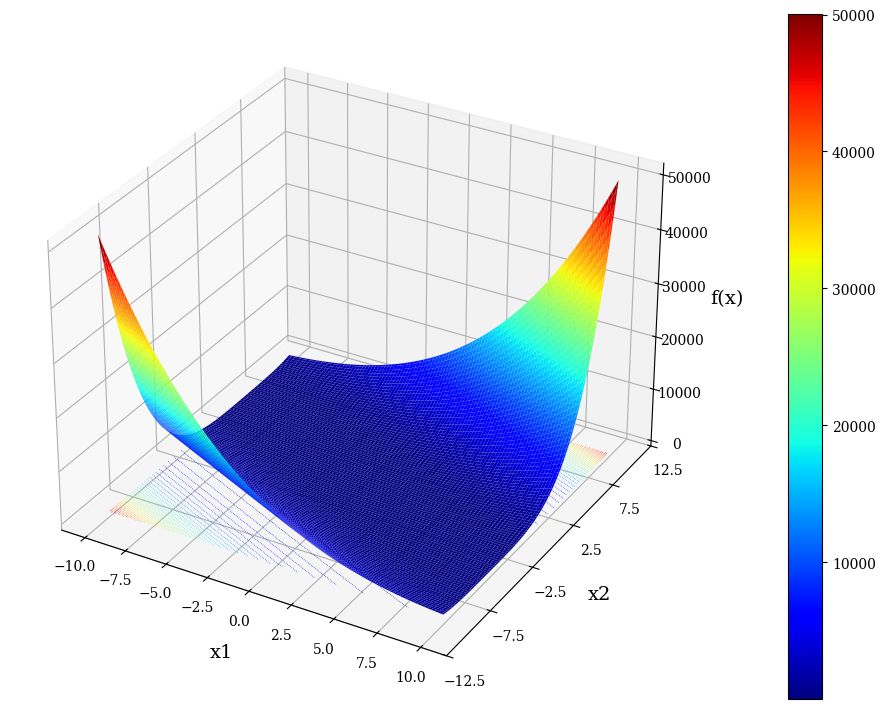

In [ ]:
from pymoo.visualization.fitness_landscape import FitnessLandscape
import numpy as np
from pymoo.util.misc import all_combinations

class LabeledFitnessLandscape(FitnessLandscape):
    def __init__(self, *args, xlabel=None, ylabel=None, zlabel=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.xlabel = xlabel
        self.ylabel = ylabel
        self.zlabel = zlabel

    def _do(self):
        problem, n_samples, _type = self.problem, self.n_samples, self._type

        # helper to reduce tick density
        def reduce_ticks(ax, axis='y', max_ticks=5):
            if axis == 'y':
                ticks = ax.get_yticks()
            else:
                ticks = ax.get_xticks()
            if len(ticks) > max_ticks:
                step = max(1, len(ticks)//max_ticks)
                new = ticks[::step]
                if new[-1] != ticks[-1]:
                    new = np.append(new, ticks[-1])
                if axis == 'y':
                    ax.set_yticks(new)
                else:
                    ax.set_xticks(new)

        # 1D case
        if problem.n_var == 1 and problem.n_obj == 1:
            self.init_figure()
            self.fig.set_size_inches(self.fig.get_size_inches() * 1.2)

            X = np.linspace(problem.xl[0], problem.xu[0], num=n_samples)[:, None]
            Z = problem.evaluate(X, return_values_of=["F"])

            import pymoo.visualization.util
            pymoo.visualization.util.plot(X, Z)

            # axis labels with larger font and slight separation
            if self.xlabel:
                self.ax.set_xlabel(self.xlabel, fontsize=14, labelpad=10)
            if self.ylabel:
                self.ax.set_ylabel(self.ylabel, fontsize=14, labelpad=10)

            # reduce y-axis ticks to at most 5
            reduce_ticks(self.ax, 'y', max_ticks=5)

        # 2D case
        elif problem.n_var == 2 and problem.n_obj == 1:
            A = np.linspace(problem.xl[0], problem.xu[0], n_samples)
            B = np.linspace(problem.xl[1], problem.xu[1], n_samples)
            X = all_combinations(A, B)
            F = np.reshape(problem.evaluate(X, return_values_of=["F"]), (n_samples, n_samples))
            _X = X[:, 0].reshape((n_samples, n_samples))
            _Y = X[:, 1].reshape((n_samples, n_samples))
            _Z = F.reshape((n_samples, n_samples))

            # plot functions
            def plot_surface():
                surf = self.ax.plot_surface(_X, _Y, _Z, **self.kwargs_surface)
                if self.colorbar:
                    cbar = self.fig.colorbar(surf, pad=0.1)
                    pos = cbar.ax.get_position()
                    cbar.ax.set_position([pos.x0 + 0.02, pos.y0, pos.width, pos.height])

            def plot_contour():
                CS = self.ax.contour(_X, _Y, _Z, self.contour_levels, **self.kwargs_contour)
                if self.kwargs_contour_labels is not None:
                    self.ax.clabel(CS, **self.kwargs_contour_labels)

            # initialize figure and enlarge
            if _type == "surface":
                self.init_figure(plot_3D=True)
                self.fig.set_size_inches(self.fig.get_size_inches() * 1.2)
                plot_surface()

            elif _type == "contour":
                self.init_figure(plot_3D=False)
                self.fig.set_size_inches(self.fig.get_size_inches() * 1.2)
                if "offset" in self.kwargs_contour:
                    del self.kwargs_contour["offset"]
                plot_contour()

            elif _type == "surface+contour":
                self.init_figure(plot_3D=True)
                self.fig.set_size_inches(self.fig.get_size_inches() * 1.2)
                plot_surface()
                plot_contour()

            else:
                raise Exception("Unknown plot type")

            # axis labels with larger font and slight separation
            if self.xlabel:
                self.ax.set_xlabel(self.xlabel, fontsize=14, labelpad=10)
            if self.ylabel:
                self.ax.set_ylabel(self.ylabel, fontsize=14, labelpad=10)
            if _type in ("surface", "surface+contour") and self.zlabel:
                self.ax.set_zlabel(self.zlabel, fontsize=14, labelpad=10)

            # reduce y-axis ticks to at most 5
            reduce_ticks(self.ax, 'y', max_ticks=5)

            # always display gridlines on x and y
            self.ax.grid(True, which='both', axis='both', linestyle='--', linewidth=0.5)

        else:
            raise Exception("Only landscapes of problems with one or two variables and one objective can be visualized.")


def set_title_style(fl, fontsize=18, fontweight='bold', fontname='DejaVu Sans'):
    fl.ax.set_title(fl.title, fontsize=fontsize, fontweight=fontweight, fontname=fontname)


# Esempio d’uso:
problem = get_problem("zakharov", n_var=2)

fl = LabeledFitnessLandscape(
    problem,
    _type="surface+contour",
    n_samples=200,
    colorbar=True,
    contour_levels=40,
    kwargs_surface={"cmap": "jet", "rstride": 2, "cstride": 2},
    kwargs_contour={'cmap': 'jet', "linestyles": "dotted", "linewidths": 0.5, "offset": 0.0},
    kwargs_contour_labels={"fontsize": 8, "inline": True, "fmt": "%1.0f"},
    figsize=(8,6),
    #title=(r"$\bf{Zakharov}$" + " - Fitness Landscape", {"fontsize": 17, 'loc': 'center'}),
    tight_layout=True,
    # qui imposti le tue label “una volta per tutte”
    xlabel=r"x1",
    ylabel=r"x2",
    zlabel=r"f(x)"
)

fl.angle = (30, 60)
'''fl._do()
set_title_style(fl, fontsize=16)'''
fl.show()


In [ ]:
import inspect
print(inspect.getsource(get_problem))

def get_problem(name, *args, **kwargs):
    name = name.lower()

    if name.startswith("bbob-"):
        from pymoo.vendor.vendor_coco import COCOProblem
        return COCOProblem(name.lower(), **kwargs)

    from pymoo.problems.multi import BNH, Carside
    from pymoo.problems.multi import CTP1, CTP2, CTP3, CTP4, CTP5, CTP6, CTP7, CTP8
    from pymoo.problems.multi import DASCMOP1, DASCMOP2, DASCMOP3, DASCMOP4, DASCMOP5, DASCMOP6, DASCMOP7, DASCMOP8, \
        DASCMOP9
    from pymoo.problems.multi import MODAct, MW1, MW2, MW3, MW4, MW5, MW6, MW7, MW8, MW9, MW10, MW11, MW12, MW13, MW14
    from pymoo.problems.single import Ackley
    from pymoo.problems.many import DTLZ1, C1DTLZ1, DC1DTLZ1, DC1DTLZ3, DC2DTLZ1, DC2DTLZ3, DC3DTLZ1, DC3DTLZ3, C1DTLZ3, \
        C2DTLZ2, C3DTLZ1, C3DTLZ4, ScaledDTLZ1, ConvexDTLZ2, ConvexDTLZ4, DTLZ2, DTLZ3, DTLZ4, DTLZ5, DTLZ6, DTLZ7, \
        InvertedDTLZ1, WFG1, WFG2, WFG3, WFG4, WFG5, WFG6, WFG7, WFG8, WFG9
    from pymoo.problems.multi import Kursa